In [56]:
# 1. Import libraries
import pandas as pd
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import fasttext
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import SelectKBest, chi2

In [57]:
# 2. Load and merge datasets
print('Loading training datasets...')
train_texts = pd.read_csv('training_datasets/train_text.csv')
train_labels = pd.read_csv('training_datasets/train_labels.csv')
train_df = pd.merge(train_texts, train_labels, on='id')

print('Loading testing datasets...')
test_texts = pd.read_csv('testing_datasets/test_text.csv')
test_labels = pd.read_csv('testing_datasets/test_labels.csv')
test_df = pd.merge(test_texts, test_labels, on='id')

print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

X_train = train_df['text']
X_test = test_df['text']
y_train = train_df['label']
y_test = test_df['label']

Loading training datasets...
Loading testing datasets...
Train size: 146068, Test size: 36517


In [ ]:
# 3. TF-IDF and FeatureUnion
print("Creating vectorizers")
word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode'
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 4),
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode'
)

feature_union = FeatureUnion([
    ('word_tfidf', word_vectorizer),
    ('char_tfidf', char_vectorizer)
])

# Use Chi-Squared for feature selection (k sets how many top features to keep)
feature_selector = SelectKBest(score_func=chi2, k=25000)
print("Done!")

Defining FeatureUnion (word ngrams + char_wb ngrams) and Chi-Squared Selector...


In [ ]:
# 4. Multinomial Naive Bayes Pipeline\n
print('Training Multinomial Naive Bayes Pipeline...')
mnb_pipeline = Pipeline([
    ('features', feature_union),
    ('selector', feature_selector),
    ('classifier', MultinomialNB())
])

start_time = time.time()
mnb_pipeline.fit(X_train, y_train)
mnb_train_time = time.time() - start_time

start_time = time.time()
mnb_preds = mnb_pipeline.predict(X_test)
mnb_test_time = time.time() - start_time

mnb_acc = accuracy_score(y_test, mnb_preds)
mnb_prec = precision_score(y_test, mnb_preds, average='macro')
mnb_rec = recall_score(y_test, mnb_preds, average='macro')
mnb_f1 = f1_score(y_test, mnb_preds, average='macro')

print(f'MNB Train Time: {mnb_train_time:.2f}s, Test Time: {mnb_test_time:.2f}s')
print(f'MNB Accuracy: {mnb_acc:.4f}')

Training Multinomial Naive Bayes Pipeline...
MNB Train Time: 30.55s, Test Time: 5.81s
MNB Accuracy: 0.7928


In [ ]:
# 5. Logistic Regression Pipeline
print('Training Logistic Regression Pipeline...')
lr_pipeline = Pipeline([
    ('features', feature_union),
    ('selector', feature_selector),
    ('classifier', LogisticRegression(max_iter=1000))
])

start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.time() - start_time

start_time = time.time()
lr_preds = lr_pipeline.predict(X_test)
lr_test_time = time.time() - start_time

lr_acc = accuracy_score(y_test, lr_preds)
lr_prec = precision_score(y_test, lr_preds, average='macro')
lr_rec = recall_score(y_test, lr_preds, average='macro')
lr_f1 = f1_score(y_test, lr_preds, average='macro')

print(f'LR Train Time: {lr_train_time:.2f}s, Test Time: {lr_test_time:.2f}s')
print(f'LR Accuracy: {lr_acc:.4f}')

Training Logistic Regression Pipeline...
LR Train Time: 32.24s, Test Time: 5.85s
LR Accuracy: 0.9037


In [ ]:
# 6. FastText
print('Training FastText...')
start_time = time.time()
ft_model = fasttext.train_supervised(input='training_datasets/train_fasttext.txt', epoch=25, lr=0.1, wordNgrams=2, verbose=2)
ft_train_time = time.time() - start_time

print('Testing FastText (Generating Predictions for Sklearn metrics)...')
start_time = time.time()
ft_raw_preds = ft_model.predict(X_test.str.replace('\n', ' ').tolist())
ft_test_time = time.time() - start_time

ft_preds = [int(float(label[0].replace('__label__', ''))) for label in ft_raw_preds[0]]
ft_acc = accuracy_score(y_test, ft_preds)
ft_prec = precision_score(y_test, ft_preds, average='macro')
ft_rec = recall_score(y_test, ft_preds, average='macro')
ft_f1 = f1_score(y_test, ft_preds, average='macro')
print(f'FastText Accuracy: {ft_acc:.4f}')


Training FastText...


Read 4M words
Number of words:  329869
Number of labels: 2
Progress: 100.0% words/sec/thread: 1707161 lr:  0.000000 avg.loss:  0.032788 ETA:   0h 0m 0s words/sec/thread: 1722873 lr:  0.045220 avg.loss:  0.058372 ETA:   0h 0m 2s


Testing FastText (Generating Predictions for Sklearn metrics)...
FastText Accuracy: 0.8761


In [ ]:
# 7. Comparison table
results_data = {
    'Model': ['Multinomial Naive Bayes', 'Logistic Regression', 'FastText'],
    'Accuracy': [mnb_acc, lr_acc, ft_acc],
    'Precision (Macro)': [mnb_prec, lr_prec, ft_prec],
    'Recall (Macro)': [mnb_rec, lr_rec, ft_rec],
    'F1-Score (Macro)': [mnb_f1, lr_f1, ft_f1],
    'Train Time (s)': [mnb_train_time, lr_train_time, ft_train_time],
    'Test Time (s)': [mnb_test_time, lr_test_time, ft_test_time]
}

results_df = pd.DataFrame(results_data)
results_df


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Train Time (s),Test Time (s)
0,Multinomial Naive Bayes,0.792781,0.768533,0.787337,0.775036,30.545452,5.806865
1,Logistic Regression,0.903743,0.904737,0.875386,0.887636,32.240320,5.849190
2,FastText,0.876058,0.881452,0.834781,0.851968,5.600531,0.417668


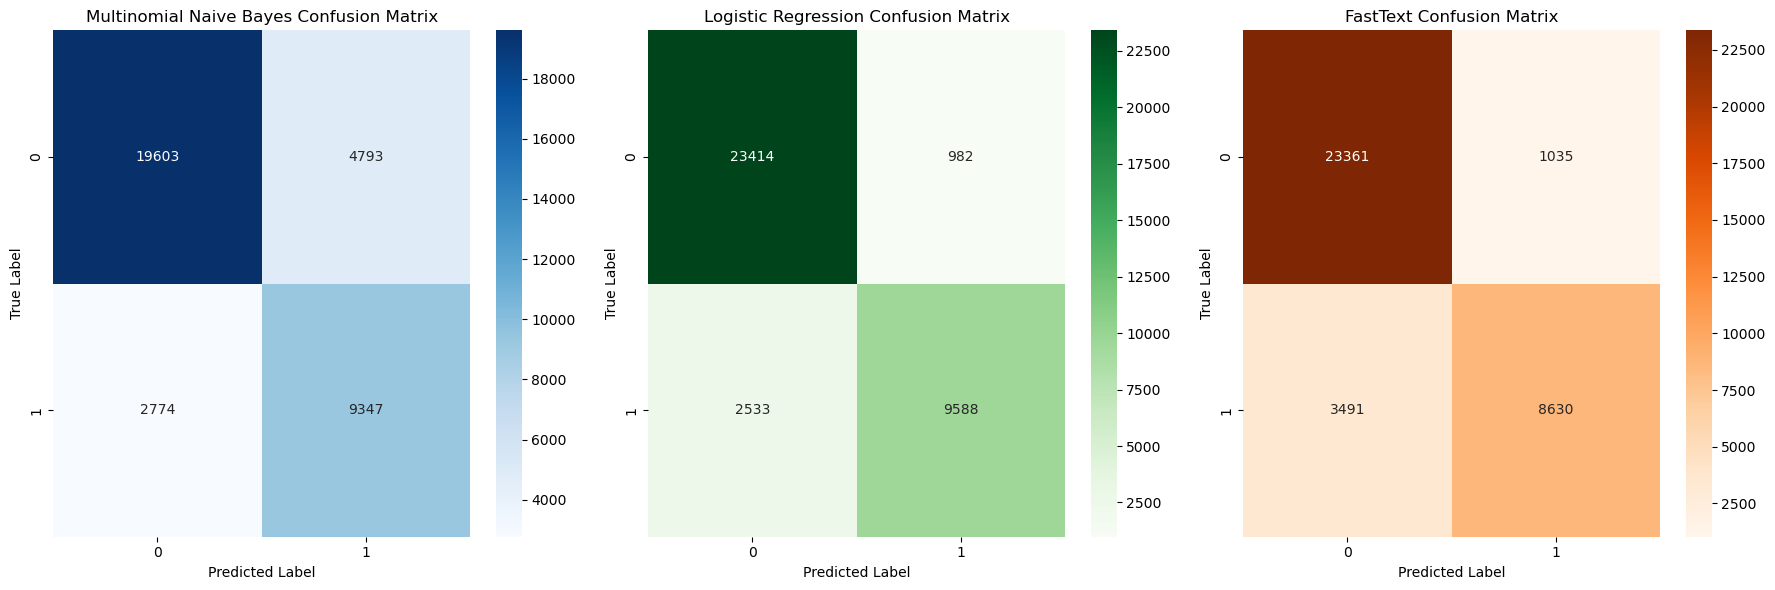

In [74]:
# 8. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cm_mnb = confusion_matrix(y_test, mnb_preds)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Multinomial Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

cm_ft = confusion_matrix(y_test, ft_preds)
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('FastText Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()


Loading test_leet.csv...
Predicting on Leetspeak Data with LR...
Leetspeak LR Test Time: 5.95s
Leetspeak LR Accuracy: 0.9850
Leetspeak LR F1 (Macro): 0.9829


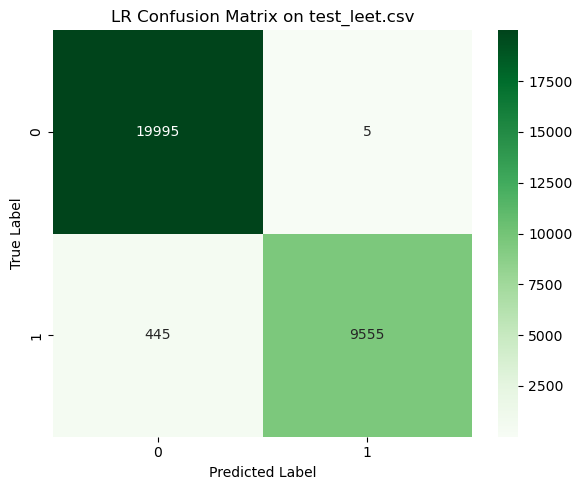

In [72]:
# 9. Logistic Regression Leetspeak Evaluation
print('Loading test_leet.csv...')
leet_df = pd.read_csv('testing_datasets/test_leet.csv')
X_leet = leet_df['text'].fillna('')
y_leet = leet_df['label']

print('Predicting on Leetspeak Data with LR...')
start_time = time.time()
leet_lr_preds = lr_pipeline.predict(X_leet)
leet_lr_test_time = time.time() - start_time

leet_lr_acc = accuracy_score(y_leet, leet_lr_preds)
leet_lr_f1 = f1_score(y_leet, leet_lr_preds, average='macro')

print(f'Leetspeak LR Test Time: {leet_lr_test_time:.2f}s')
print(f'Leetspeak LR Accuracy: {leet_lr_acc:.4f}')
print(f'Leetspeak LR F1 (Macro): {leet_lr_f1:.4f}')

# Confusion Matrix for Leetspeak LR
fig, ax = plt.subplots(figsize=(6, 5))
cm_leet_lr = confusion_matrix(y_leet, leet_lr_preds)
sns.heatmap(cm_leet_lr, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_title('LR Confusion Matrix on test_leet.csv')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()


Converting test_leet.csv to FastText format...
Evaluating FastText on Leetspeak Data...
Leetspeak FastText Test Time: 0.32s
Leetspeak FastText Accuracy: 0.9696
Leetspeak FastText F1 (Macro): 0.9650


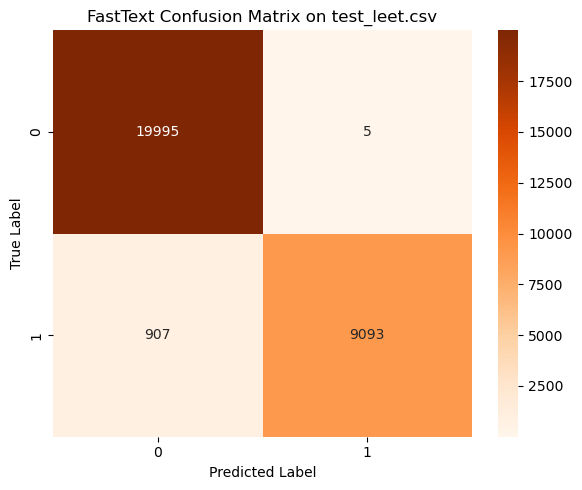

In [73]:
# 10. Convert Leetspeak Data to FastText format and Evaluate
print('Converting test_leet.csv to FastText format...')
with open('testing_datasets/test_leet_fasttext.txt', 'w', encoding='utf-8') as f:
    for _, row in leet_df.iterrows():
        text = str(row['text']).replace('\n', ' ')
        f.write(f'__label__{int(float(row["label"]))} {text}\n')

print('Evaluating FastText on Leetspeak Data...')
start_time = time.time()
ft_leet_raw_preds = ft_model.predict(X_leet.str.replace('\n', ' ').tolist())
leet_ft_test_time = time.time() - start_time

leet_ft_preds = [int(float(label[0].replace('__label__', ''))) for label in ft_leet_raw_preds[0]]

leet_ft_acc = accuracy_score(y_leet, leet_ft_preds)
leet_ft_f1 = f1_score(y_leet, leet_ft_preds, average='macro')

print(f'Leetspeak FastText Test Time: {leet_ft_test_time:.2f}s')
print(f'Leetspeak FastText Accuracy: {leet_ft_acc:.4f}')
print(f'Leetspeak FastText F1 (Macro): {leet_ft_f1:.4f}')

# Confusion Matrix for Leetspeak FastText
fig, ax = plt.subplots(figsize=(6, 5))
cm_leet_ft = confusion_matrix(y_leet, leet_ft_preds)
sns.heatmap(cm_leet_ft, annot=True, fmt='d', cmap='Oranges', ax=ax)
ax.set_title('FastText Confusion Matrix on test_leet.csv')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()
